# Rastermap — Análisis exploratorio de calcio
**Sorting no supervisado de neuronas por Rastermap (Stringer & Pachitariu)**

Conserva la misma estructura de carpetas y funciones de descubrimiento del pipeline
original. Aquí **solo** se hace: cargar los trazos → correr Rastermap → visualizar
el raster ordenado. No se calcula OSI/DSI ni el análisis poblacional.

---
### Estructura de carpetas esperada
```
Calcio/
├── BTBR_V1/                  ← nombre de carpeta define genotipo
│   ├── animal_fecha/
│   │   ├── *reg*.txt         ← registro microscopio (opcional, solo para marcar estímulos)
│   │   ├── *pas*.txt         ← registro estímulos (opcional, solo para marcar estímulos)
│   │   └── *traces*.csv      ← trazos de calcio
│   └── ...
└── C57_V1/
    └── ...
```
### Secciones
1. Dependencias
2. Configuración
3. Funciones — descubrimiento de archivos y carga de trazos
4. Funciones — estímulos (opcional, solo para marcar líneas en el raster)
5. Loop principal — correr Rastermap por animal
6. Visualización — raster individual por animal
7. Visualización — comparación por genotipo

## 1. Dependencias

In [1]:
#pip install rastermap

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import zscore
import warnings, traceback
from rastermap import Rastermap
warnings.filterwarnings('ignore')
print('Dependencias cargadas.')

Dependencias cargadas.


## 2. Configuración\n**Edita solo esta celda.**

In [3]:
# ─── RUTAS ────────────────────────────────────────────────────────────────────
DATA_ROOT = r'D:\AL-205\Nicole\Calcio\Nueva carpeta'  # <── cambia esto

# Keywords para detectar archivos (case-insensitive, busca subcadena en nombre)
SCOPE_KEYWORD  = 'reg'     # TXT del microscopio (solo se usa si SHOW_STIM_ONSETS=True)
STIM_KEYWORD   = 'pas'     # TXT de estímulos    (solo se usa si SHOW_STIM_ONSETS=True)
TRACES_KEYWORD = 'traces'  # CSV de trazos de calcio

TRACES_REQUIRE  = 'OryDir'       # el archivo de trazos DEBE contener esto
TRACES_EXCLUDE  = ['espontaneo'] # y NO debe contener ninguno de estos

# Carpetas de grupo → genotipo
GENOTYPE_FOLDERS = {
    'BTBR': 'BTBR',
    'C57':  'C57',
}

# ─── ADQUISICIÓN ──────────────────────────────────────────────────────────────
SAMPLING_RATE = 5           # Hz
MS_PER_FRAME  = 1000 / SAMPLING_RATE  # 200 ms
MIN_STIM_INTERVAL_S = 1.0  # banderas del mismo tipo mas cerca que esto se consideran rebote de Arduino

# ─── RASTERMAP ────────────────────────────────────────────────────────────────
# Ver todos los parámetros en Rastermap? — estos son un punto de partida razonable
# para datos de calcio con pocas a moderadas neuronas por sesión.
RASTERMAP_PARAMS = dict(
    n_clusters      = 100,   # baja esto si tienes pocas neuronas (< 100)
    n_PCs           = 128,   # no puede ser mayor al numero de neuronas
    locality        = 0.5,   # 0 = orden global, 1 = muy local / busca secuencias
    time_lag_window = 5,     # util para estructura temporal (secuencias)
    verbose         = False,
)

# Poner en False si no quieres cargar los TXT de estímulo (solo rastermap puro)
SHOW_STIM_ONSETS = True

# ─── OUTPUT ───────────────────────────────────────────────────────────────────
OUTPUT_DIR = Path(DATA_ROOT) / 'rastermap_output'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Configuracion cargada.')
print(f'Output → {OUTPUT_DIR}')

Configuracion cargada.
Output → D:\AL-205\Nicole\Calcio\Nueva carpeta\rastermap_output


## 3. Funciones — descubrimiento de archivos y carga de trazos

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 1 — Detección de archivos (igual que el pipeline original)
# ══════════════════════════════════════════════════════════════════════════════

def find_file(folder: Path, keyword: str) -> Path:
    """Busca el primer archivo cuyo nombre contiene keyword (case-insensitive)."""
    kw = keyword.lower()
    matches = [f for f in folder.iterdir()
               if f.is_file() and kw in f.name.lower()]
    if not matches:
        raise FileNotFoundError(
            f"No encontre archivo con '{keyword}' en {folder}")
    txt_matches = [f for f in matches if f.suffix.lower() == '.txt']
    csv_matches = [f for f in matches if f.suffix.lower() == '.csv']
    if kw in ['reg', 'pas']:
        return txt_matches[0] if txt_matches else matches[0]
    else:  # traces → preferir CSV
        return csv_matches[0] if csv_matches else matches[0]


def detect_genotype(group_name: str) -> str:
    for kw, geno in GENOTYPE_FOLDERS.items():
        if kw.upper() in group_name.upper():
            return geno
    return 'Unknown'


def discover_animals(root: str) -> list:
    """Recorre dos niveles: grupo/animal."""
    root = Path(root)
    animals = []
    for group in sorted(root.iterdir()):
        if not group.is_dir() or group.name.startswith('.') \
                or group.name == 'rastermap_output':
            continue
        genotype = detect_genotype(group.name)
        for animal in sorted(group.iterdir()):
            if not animal.is_dir() or animal.name.startswith('.'):
                continue
            animals.append({
                'animal_id': animal.name,
                'genotype':  genotype,
                'group':     group.name,
                'folder':    animal,
            })
    return animals


# ══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 2 — Carga de trazos
# ══════════════════════════════════════════════════════════════════════════════

def load_traces(traces_csv: Path) -> np.ndarray:
    """Carga la matriz de trazos completa (misma lectura que el pipeline
    original: decimal coma, separador auto-detectado) y la regresa como
    spks con shape (neuronas, frames), z-scoreada por neurona — el formato
    que espera Rastermap."""
    df = pd.read_csv(traces_csv, decimal=',', sep=None, engine='python')
    if df.columns[0].lower() in ['unnamed: 0', 'index', 'time', 'frame']:
        df.drop(df.columns[0], axis=1, inplace=True)
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    spks = df.values.T                    # (neuronas, frames)
    spks = zscore(spks, axis=1)
    spks = np.nan_to_num(spks)
    return spks.astype('float32')


print('Funciones cargadas.')

Funciones cargadas.


## 4. Funciones — estímulos (opcional)
Solo para dibujar líneas verticales donde empezó cada estímulo sobre el raster.
Si `SHOW_STIM_ONSETS = False` esta sección no se usa y puedes saltarla.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  MÓDULO 3 — Parsers de TXT y alineación (idéntico al pipeline original)
# ══════════════════════════════════════════════════════════════════════════════

def parse_scope_txt(filepath: Path) -> tuple:
    """Formato: HH:MM:SS.microsec.frameN.flag.canal"""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit = [l.strip().split('.') for l in lines[1:]]
    datasplit = [d for d in datasplit if len(d) >= 4]
    timestamp_strs = [d[0] for d in datasplit]
    millisec  = np.array([float(d[2]) for d in datasplit])
    sensores  = np.array([float(d[3]) for d in datasplit])
    millisec  = millisec - millisec[0]
    return timestamp_strs, millisec, sensores


def parse_stim_txt(filepath: Path) -> tuple:
    """Formato: HH:MM:SS.mmm.FLAG (11=inicio del estimulo, 0XXX=angulo)"""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit    = [l.strip().split('.') for l in lines]
    datasplit    = [d for d in datasplit if len(d) >= 3]
    tstamp_stlog = [d[0] for d in datasplit]
    millisec_frac = np.array([float(d[1]) for d in datasplit])
    estimulos    = np.array([float(d[2]) for d in datasplit])
    return tstamp_stlog, millisec_frac, estimulos

def _hms_to_seconds(ts: str) -> float:
    h, m, s = map(int, ts.split(':'))
    return h * 3600 + m * 60 + s


def debounce_stim_events(tstamp_stlog, millisec_frac, estimulos,
                          min_interval_s: float = MIN_STIM_INTERVAL_S) -> tuple:
    """Elimina banderas repetidas del mismo tipo que llegan demasiado
    seguido (rebote del Arduino) — se queda solo con la primera bandera
    dentro de min_interval_s. No toca banderas de tipos distintos aunque
    esten pegadas en tiempo."""
    t_sec = np.array([_hms_to_seconds(ts) for ts in tstamp_stlog]) + millisec_frac / 1000.0
    keep    = np.ones(len(estimulos), dtype=bool)
    last_t  = {}
    for i in range(len(estimulos)):
        flag = estimulos[i]
        t    = t_sec[i]
        if flag in last_t and (t - last_t[flag]) < min_interval_s:
            keep[i] = False
        else:
            last_t[flag] = t
    tstamp_out = [ts for ts, k in zip(tstamp_stlog, keep) if k]
    return tstamp_out, millisec_frac[keep], estimulos[keep]


def get_clean_frame_times(millisec: np.ndarray, sensores: np.ndarray,
                           min_interval_ms: float = 100.0) -> np.ndarray:
    """Extrae tiempos de frames reales (flag==23), eliminando duplicados."""
    framt    = np.where(sensores == 23)[0]
    t_fram   = millisec[framt]
    ll       = np.diff(t_fram)
    idx_keep = np.where(ll > min_interval_ms)[0] + 1
    return np.insert(t_fram[idx_keep], 0, t_fram[0])


def align_stimuli_to_frames(timestamp_strs, millisec, sensores,
                             tstamp_stlog, estimulos,
                             ms_per_frame: float = 200.0) -> np.ndarray:
    """Devuelve stimsnframes (n_angulos, n_trials, 2):
       [:,:,0] = ángulo, [:,:,1] = frame de inicio."""
    t_fram_clean = get_clean_frame_times(millisec, sensores)
    max_frame    = len(t_fram_clean) - 1

    stims_all, stim_counts = np.unique(estimulos, return_counts=True)
    stims    = stims_all[stims_all != 11]
    n_trials = int(stim_counts[stims_all == 11][0]) if 11 in stims_all else \
               int(np.min(stim_counts[stims_all != 11]))

    idx_t_stim = np.zeros((n_trials, len(stims)))

    ts_arr = np.array(timestamp_strs)
    for s, stim in enumerate(stims):
        t_stamp_idx = np.where(estimulos == stim)[0]
        t_stamp     = [tstamp_stlog[i - 1] for i in t_stamp_idx]
        for j, ts in enumerate(t_stamp):
            if j >= n_trials:
                break
            hms = list(map(int, ts.split(':')))
            hms[2] += 1
            ts2 = f"{hms[0]:02}:{hms[1]:02}:{hms[2]:02}"
            idx_bin = np.concatenate((
                np.where(ts_arr == ts)[0],
                np.where(ts_arr == ts2)[0]
            ))
            if len(idx_bin) > 0:
                idx_stim_j = np.where(
                    sensores[idx_bin[0]:idx_bin[-1]] == 4
                )[0] + idx_bin[0]
                if len(idx_stim_j) > 0:
                    idx_t_stim[j, s] = idx_stim_j[0]

    t_Stim_ms   = millisec[idx_t_stim.astype(int)]
    tf          = np.round(t_Stim_ms / ms_per_frame).astype(int)
    tf_clamped  = np.clip(tf, 0, max_frame)
    a           = t_Stim_ms - t_fram_clean[tf_clamped] > ms_per_frame
    tf[a]      += 1
    tf          = np.clip(tf, 0, max_frame).T  # (n_angulos, n_trials)

    stims_tiled  = np.tile(stims[:, np.newaxis], (1, tf.shape[1]))
    stimsnframes = np.stack([stims_tiled, tf], axis=2)
    return stimsnframes


def get_stim_onset_frames(scope_file: Path, stim_file: Path) -> tuple:
    """Regresa (frames, angulos) de inicio de cada estimulo, ordenados en
    el tiempo — solo para marcar lineas verticales en el raster."""
    ts_strs, millisec, sensores          = parse_scope_txt(scope_file)
    tstamp_stlog, millisec_frac, estimulos = parse_stim_txt(stim_file)
    tstamp_stlog, millisec_frac, estimulos = debounce_stim_events(
        tstamp_stlog, millisec_frac, estimulos)
    stimsnframes = align_stimuli_to_frames(
        ts_strs, millisec, sensores, tstamp_stlog, estimulos,
        ms_per_frame=MS_PER_FRAME)
    angles = stimsnframes[:, :, 0].flatten()
    frames = stimsnframes[:, :, 1].flatten().astype(int)
    order  = np.argsort(frames)
    return frames[order], angles[order]


print('Funciones de estimulos cargadas.')

Funciones de estimulos cargadas.


## 5. Loop principal — descubrir animales y correr Rastermap

In [6]:
animals = discover_animals(DATA_ROOT)
print(f'Animales encontrados: {len(animals)}')
for a in animals:
    print(f"  [{a['genotype']:6}]  {a['group']}/{a['animal_id']}")

Animales encontrados: 12
  [BTBR  ]  BTBR/BTBR_R2_060725
  [BTBR  ]  BTBR/BTBR_R2_270923_hembra_pasiva_Isaac
  [BTBR  ]  BTBR/BTBRL1030825_Reg_12_12_25
  [BTBR  ]  BTBR/BTBRR1_280825_Reg_15_12_25
  [BTBR  ]  BTBR/BTBRSM_270923_hembra_isaac
  [C57   ]  C57/C57_SM_Isaac
  [C57   ]  C57/C57L10300325_pasiva
  [C57   ]  C57/C57L2_Isaac
  [C57   ]  C57/C57R1230825_Reg_15_12_25
  [C57   ]  C57/C57R20010525_pasiva
  [C57   ]  C57/C57R3230825_Reg_15_12_25
  [C57   ]  C57/Delta 4-22 wt


In [7]:
rastermap_data = {}
failed = []

for animal in animals:
    aid    = animal['animal_id']
    folder = animal['folder']
    geno   = animal['genotype']
    sep    = '=' * 60
    print(f'\n{sep}')
    print(f'  Procesando: {aid}  [{geno}]')
    print(sep)

    try:
        traces_file = find_file(folder, TRACES_KEYWORD)
        print(f'  traces : {traces_file.name}')

        spks = load_traces(traces_file)
        print(f'  spks   : {spks.shape}  (neuronas, frames)')

        onset_frames, onset_angles = None, None
        if SHOW_STIM_ONSETS:
            try:
                scope_file = find_file(folder, SCOPE_KEYWORD)
                stim_file  = find_file(folder, STIM_KEYWORD)
                onset_frames, onset_angles = get_stim_onset_frames(scope_file, stim_file)
                print(f'  estimulos detectados: {len(onset_frames)}')
            except Exception:
                print('  (sin marcas de estimulo disponibles — solo rastermap)')

        # n_PCs no puede exceder el numero de neuronas
        params = dict(RASTERMAP_PARAMS)
        params['n_PCs'] = min(params['n_PCs'], spks.shape[0])

        model = Rastermap(**params).fit(spks)

        rastermap_data[aid] = {
            'genotype':      geno,
            'X_embedding':   model.X_embedding,
            'isort':         model.isort,
            'embedding':     model.embedding,
            'n_neurons':     spks.shape[0],
            'n_frames':      spks.shape[1],
            'onset_frames':  onset_frames,
            'onset_angles':  onset_angles,
        }
        print('  Rastermap ajustado.')

    except Exception:
        print(f'  ERROR en {aid}:')
        traceback.print_exc()
        failed.append(aid)

sep = '=' * 60
print(f'\n{sep}')
print(f'Exitosos: {len(rastermap_data)} / {len(animals)}')
if failed:
    print(f'Fallidos: {failed}')


  Procesando: BTBR_R2_060725  [BTBR]
  traces : machoR2_060725_BTBR_pasiva_OryDir_CTraces.csv
  spks   : (187, 6103)  (neuronas, frames)
  estimulos detectados: 720
  Rastermap ajustado.

  Procesando: BTBR_R2_270923_hembra_pasiva_Isaac  [BTBR]
  traces : BTBR_HEMBRA_R2_DIA2_OryDir_Ctraces.csv
  spks   : (93, 4449)  (neuronas, frames)
  estimulos detectados: 576
  Rastermap ajustado.

  Procesando: BTBRL1030825_Reg_12_12_25  [BTBR]
  traces : BTBRL1030825_OryDir_12_12_25_C_TRACES.csv
  spks   : (92, 3021)  (neuronas, frames)
  estimulos detectados: 720
  Rastermap ajustado.

  Procesando: BTBRR1_280825_Reg_15_12_25  [BTBR]
  traces : BTBRR1_280825_OryDir_15_12_25_C_TRACES.csv
  spks   : (127, 5500)  (neuronas, frames)
  estimulos detectados: 720
  Rastermap ajustado.

  Procesando: BTBRSM_270923_hembra_isaac  [BTBR]
  traces : BTBR_SM_HEMBRA_PASIVA_OryDir_CTraces.csv
  spks   : (20, 4382)  (neuronas, frames)
  estimulos detectados: 576
  Rastermap ajustado.

  Procesando: C57_SM_Isaac

## 6. Visualización — raster individual por animal
Neuronas ordenadas por Rastermap (eje Y), tiempo en frames (eje X).
Las líneas rojas marcan inicio de estímulo, si `SHOW_STIM_ONSETS=True`.

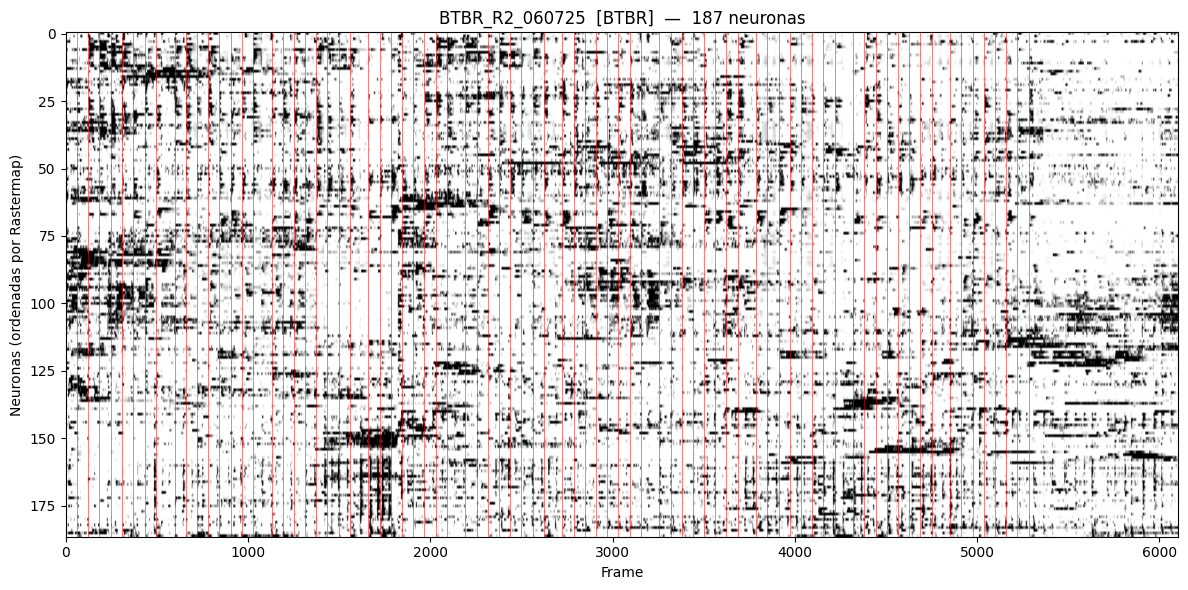

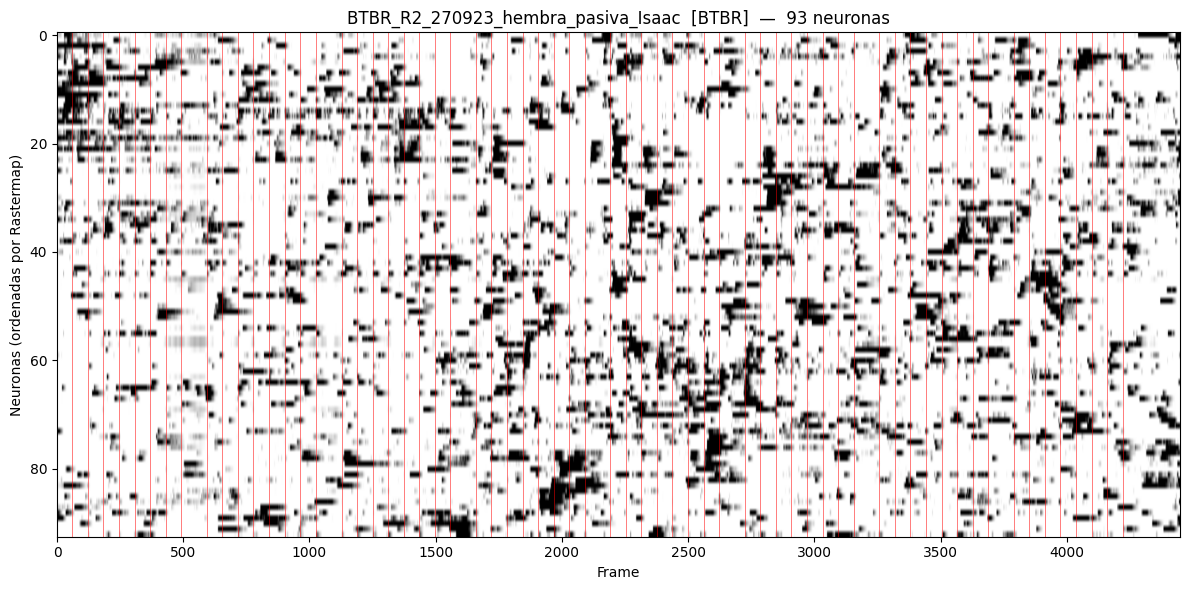

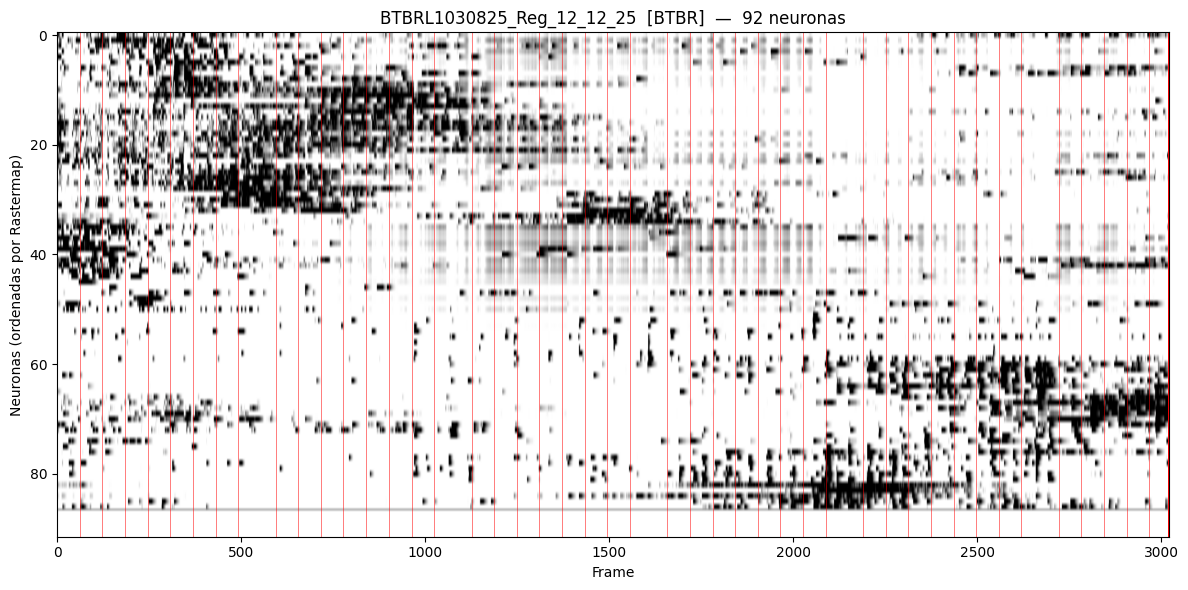

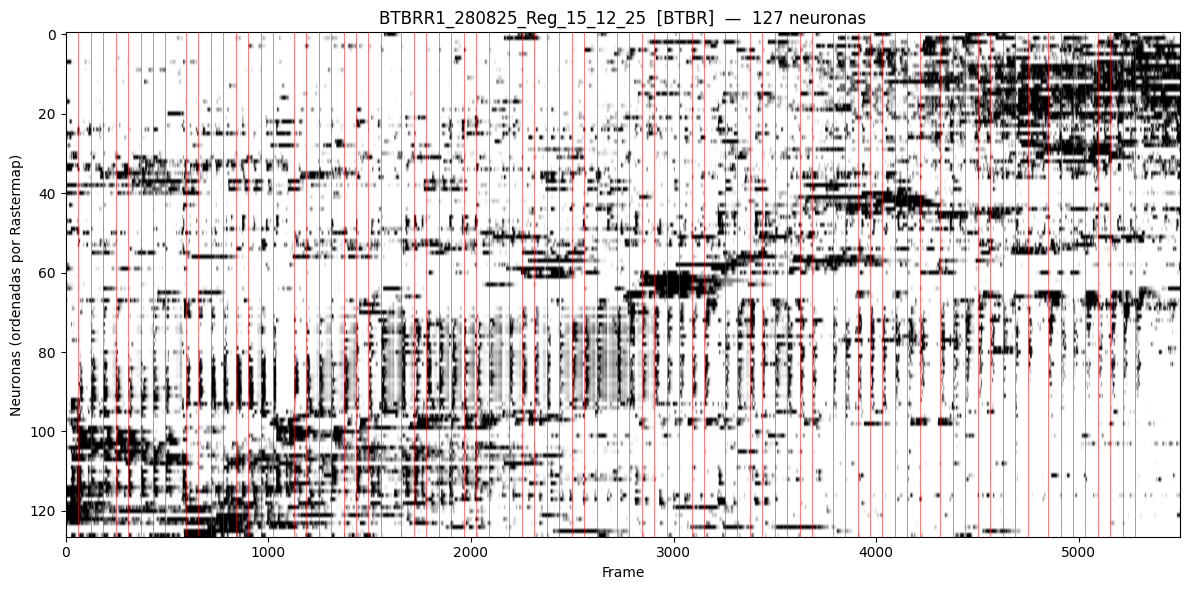

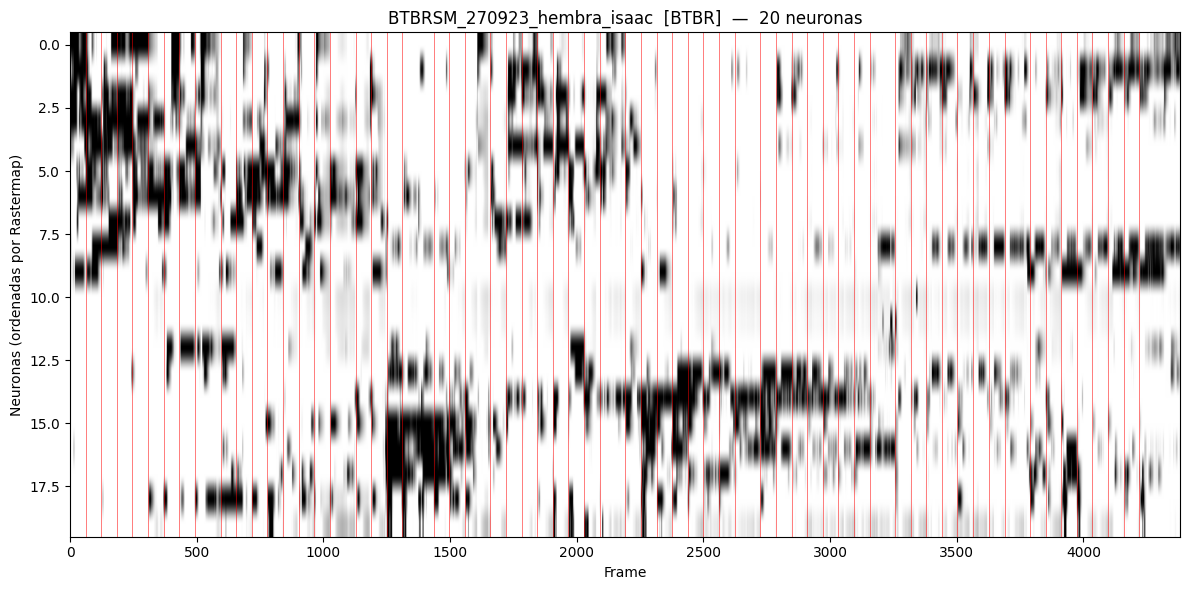

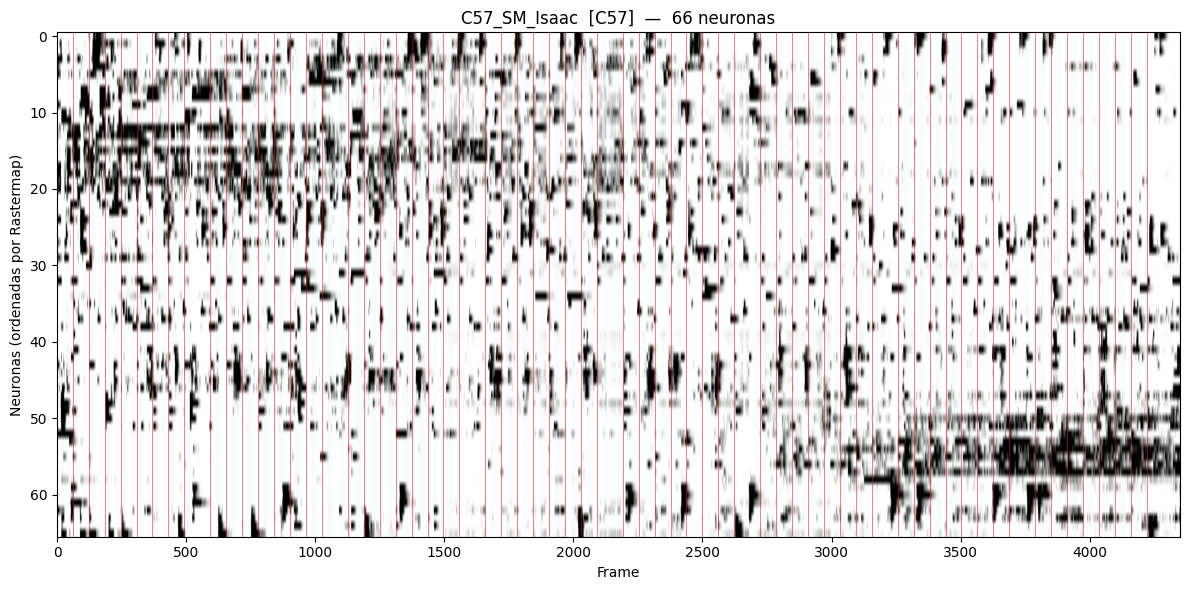

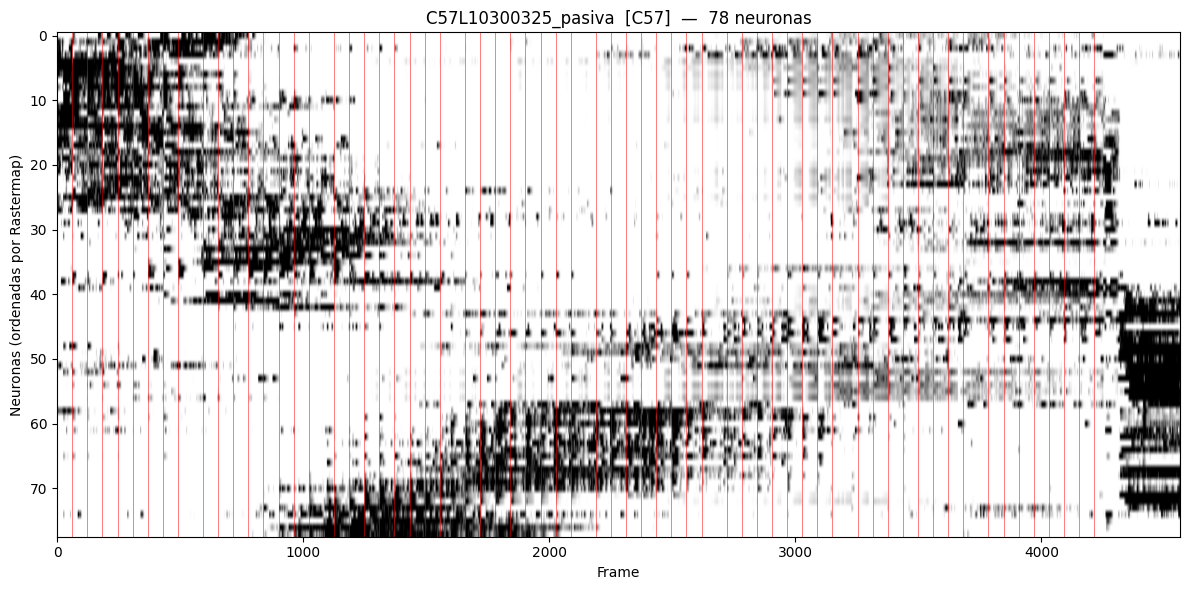

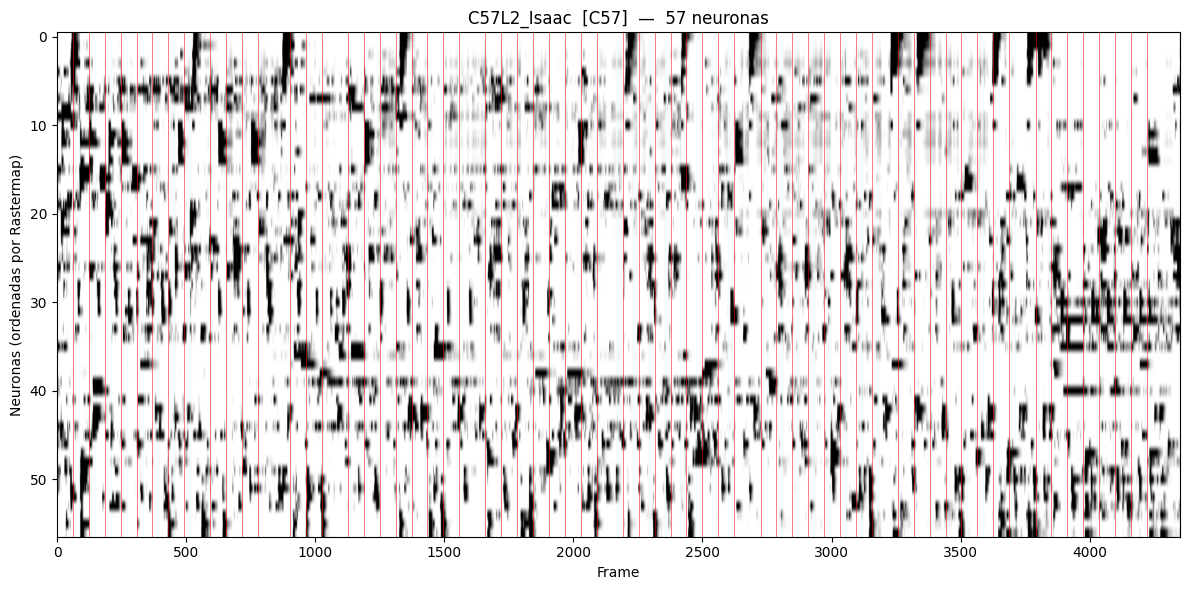

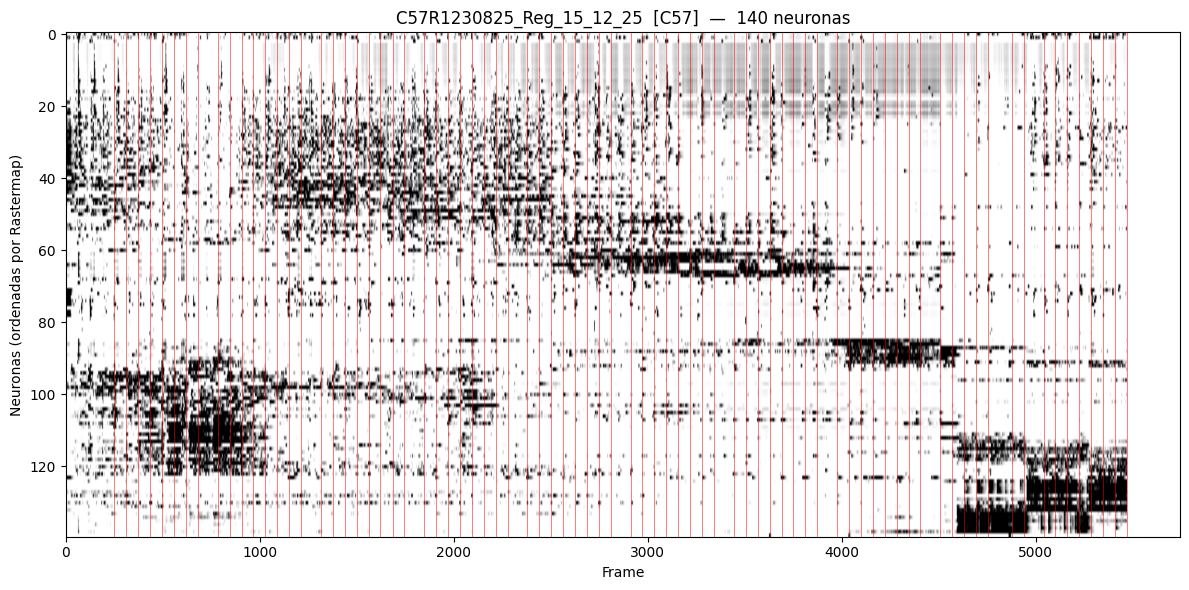

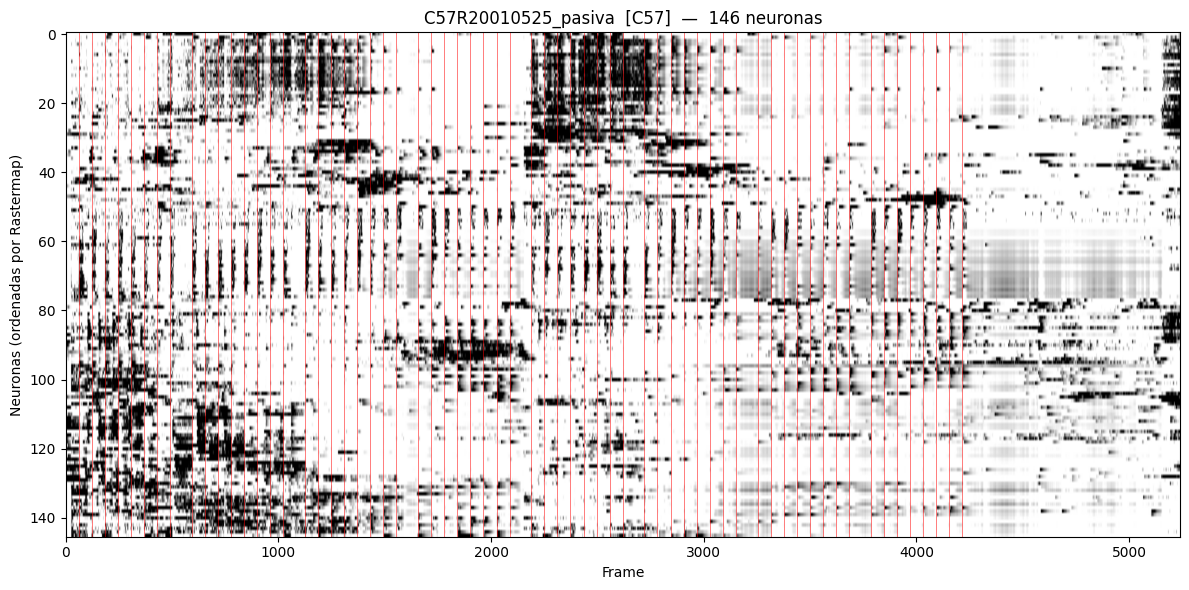

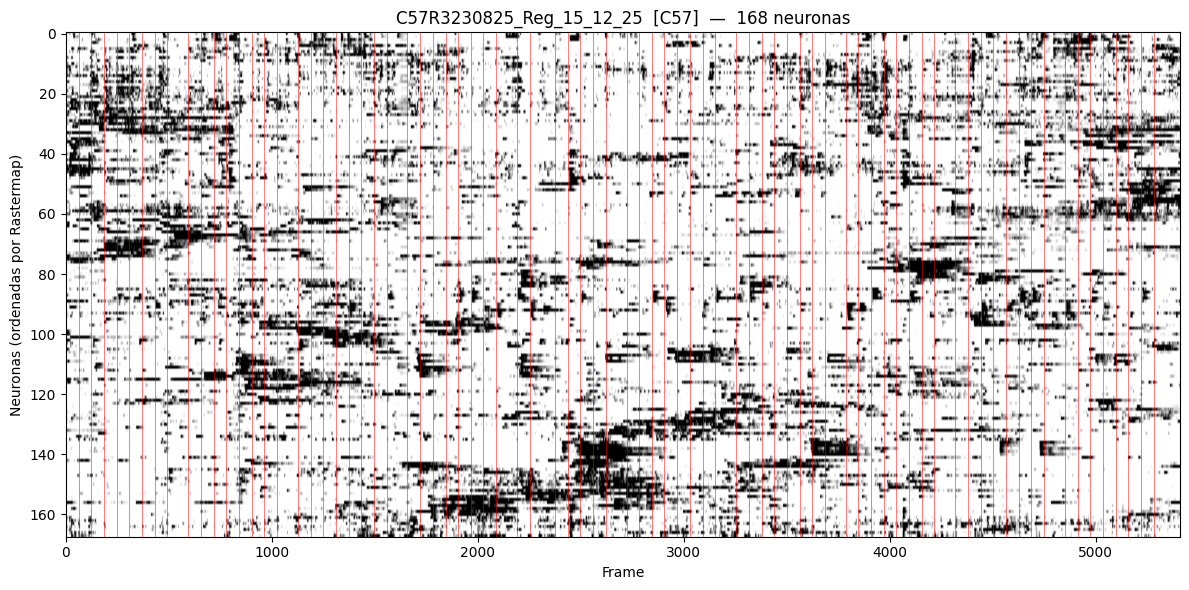

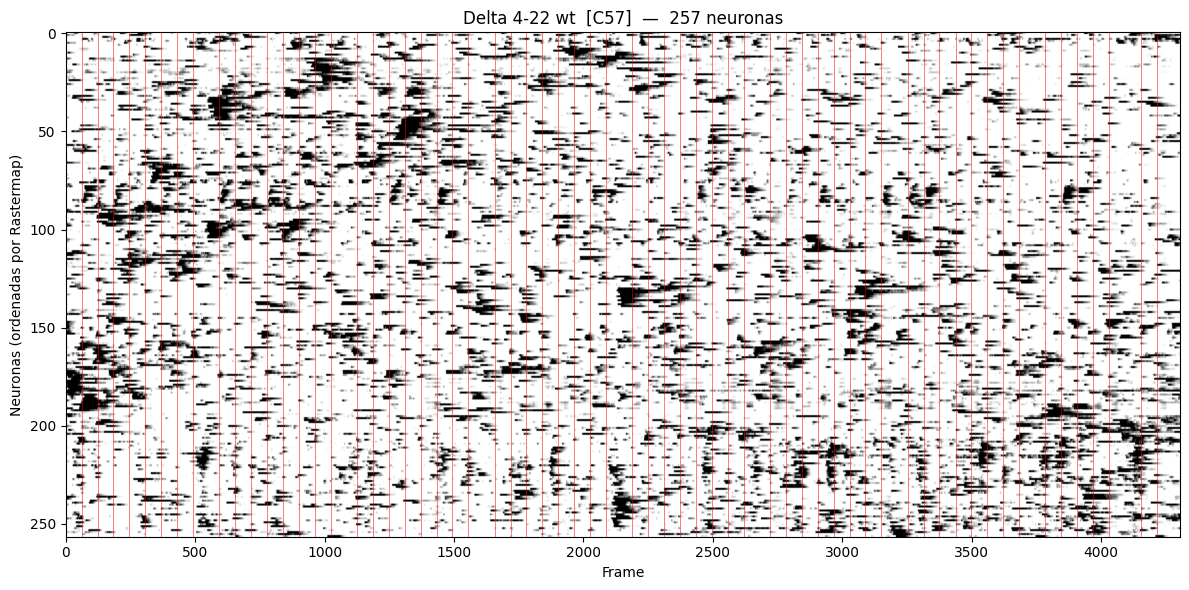

In [8]:
for aid, data in rastermap_data.items():
    X = data['X_embedding']

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(X, cmap='gray_r', vmin=0, vmax=1.5, aspect='auto')

    if data['onset_frames'] is not None:
        for f in data['onset_frames']:
            ax.axvline(f, color='red', lw=0.6, alpha=0.6)

    ax.set_xlabel('Frame')
    ax.set_ylabel('Neuronas (ordenadas por Rastermap)')
    ax.set_title(f"{aid}  [{data['genotype']}]  —  {data['n_neurons']} neuronas")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{aid}_rastermap.svg', format='svg', bbox_inches='tight')
    plt.show()

## 7. Visualización — comparación por genotipo
Cuadrícula con todos los animales agrupados por genotipo, para escaneo visual rápido.

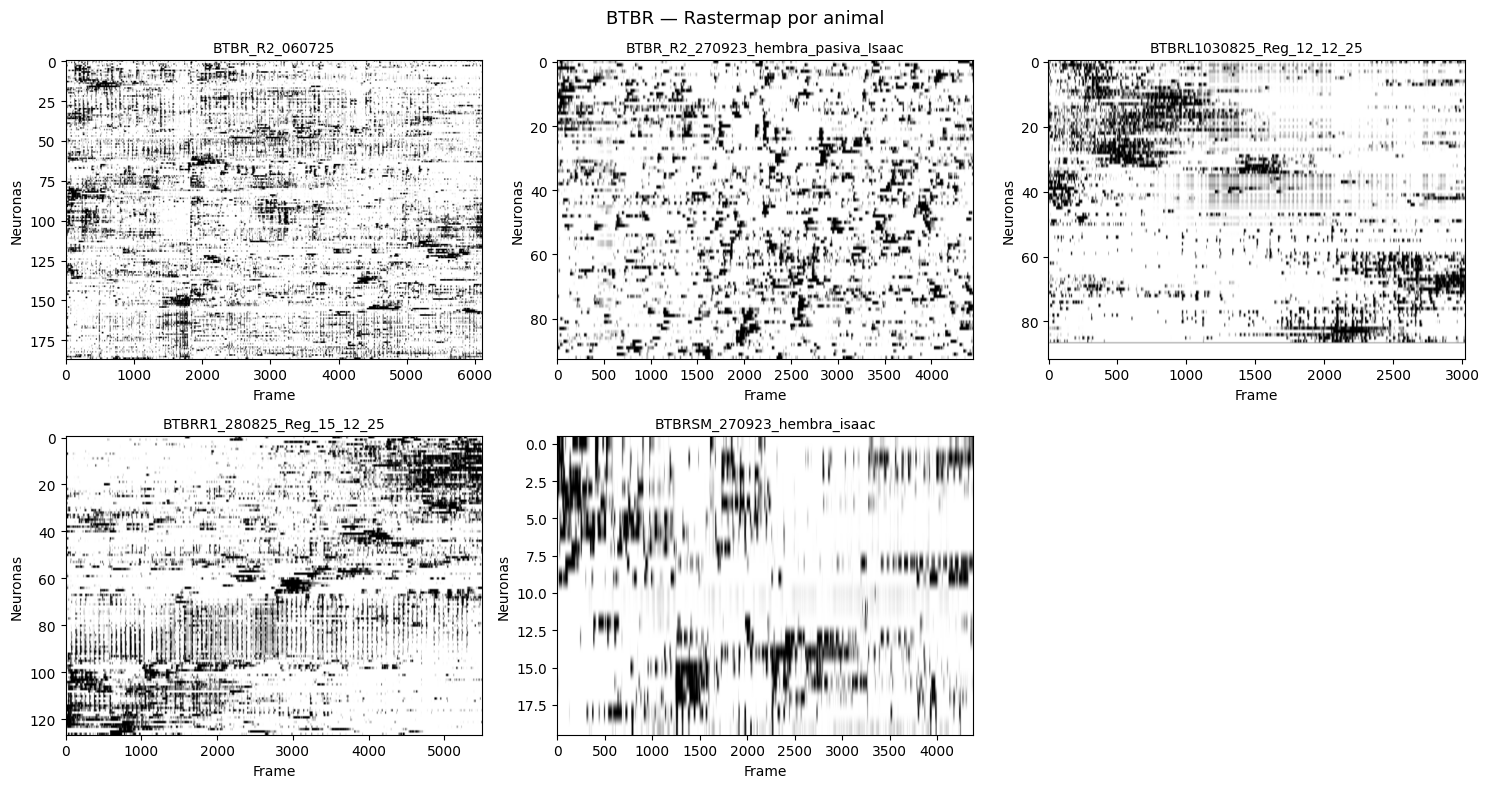

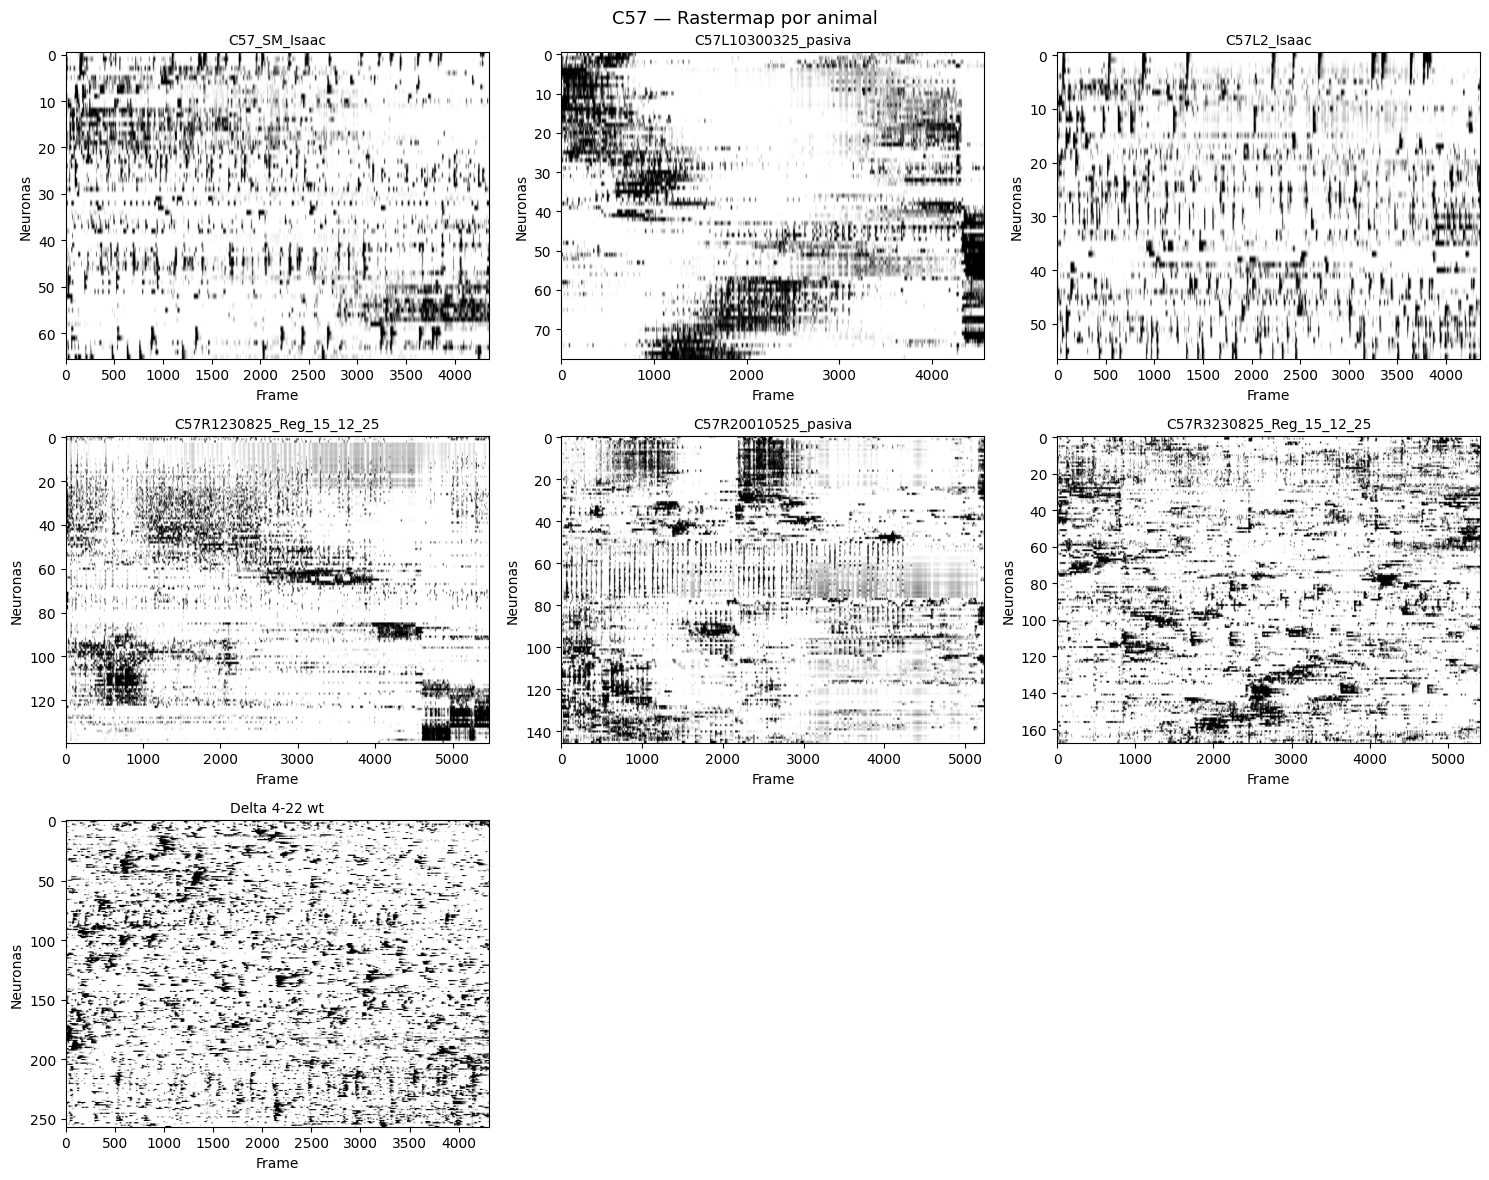

In [9]:
genotypes = sorted(set(d['genotype'] for d in rastermap_data.values()))

for geno in genotypes:
    ids_geno = [aid for aid, d in rastermap_data.items() if d['genotype'] == geno]
    n = len(ids_geno)
    if n == 0:
        continue
    n_cols = min(3, n)
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
    axes = np.array(axes).flatten()

    for i, aid in enumerate(ids_geno):
        X = rastermap_data[aid]['X_embedding']
        axes[i].imshow(X, cmap='gray_r', vmin=0, vmax=1.5, aspect='auto')
        axes[i].set_title(aid, fontsize=10)
        axes[i].set_xlabel('Frame')
        axes[i].set_ylabel('Neuronas')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{geno} — Rastermap por animal', fontsize=13)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{geno}_rastermap_grid.svg', format='svg', bbox_inches='tight')
    plt.show()